In [1]:
import os
import pandas as pd
import tensorflow as tf

base_directory = "./dataset/iam_words/words/" 
words_file = os.path.join(base_directory, "words.txt")


In [3]:
def parse_iam_dataset(words_txt_path, images_base_dir):
    parsed_data = []
    missing_count = 0
    
    with open(words_txt_path, 'r') as file:
        lines = file.readlines()
        
    for line in lines:
        if line.startswith('#'):
            continue
            
        parts = line.strip().split()
        
        if not parts or len(parts) < 9:
            continue
            
        word_id = parts[0]
        seg_result = parts[1]
        
        if seg_result == 'ok':
            transcription = " ".join(parts[8:])
            id_parts = word_id.split('-')
            
            if len(id_parts) >= 2:
                folder1 = id_parts[0]
                folder2 = f"{id_parts[0]}-{id_parts[1]}"
                img_filename = f"{word_id}.png"
                
                img_path = os.path.join(images_base_dir, folder1, folder2, img_filename)
                
                
                if os.path.exists(img_path):
                    parsed_data.append({
                        'image_path': img_path,
                        'label': transcription
                    })
                else:
                    missing_count += 1
                    
                    if missing_count == 1:
                        print(f"Cannot find file at -> {os.path.abspath(img_path)}")
            
    df = pd.DataFrame(parsed_data, columns=['image_path', 'label'])
    
    print(f"Found {len(parsed_data)} valid images.")
    print(f"Could not find {missing_count} images.")
    
    return df

In [4]:
print("Parsing words.txt")
df = parse_iam_dataset(words_file, base_directory)

print(f"Successfully parsed {len(df)} valid images.")

df.head()

Parsing words.txt
Found 38305 valid images.
Could not find 0 images.
Successfully parsed 38305 valid images.


,image_path,label
0,./dataset/iam_words/words/a01\a01-000u\a01-000...,A
1,./dataset/iam_words/words/a01\a01-000u\a01-000...,MOVE
2,./dataset/iam_words/words/a01\a01-000u\a01-000...,to
3,./dataset/iam_words/words/a01\a01-000u\a01-000...,stop
4,./dataset/iam_words/words/a01\a01-000u\a01-000...,Mr.


In [5]:
# Define our exact vocabulary
vocab = sorted(list(set("abcdefghijklmnopqrstuvwxyzABCDEFGHIJKLMNOPQRSTUVWXYZ0123456789.,;:'!?()[]{}- \"")))
valid_chars = set(vocab)

def is_valid_label(text):
    # Drop empty strings
    if type(text) != str or len(text.strip()) == 0:
        return False
    # Drop strings that contain unknown characters
    for char in text:
        if char not in valid_chars:
            return False
    return True

print(f"Dataset size before strict cleaning: {len(df)}")

# Apply the strict filter and reset index
df = df[df['label'].apply(is_valid_label)]
df = df.reset_index(drop=True)

print(f"Dataset size after strict cleaning: {len(df)}")



Dataset size before strict cleaning: 38305
Dataset size after strict cleaning: 38257


In [6]:
char_to_num = tf.keras.layers.StringLookup(vocabulary=vocab, mask_token=None)

# Standard dimensions for a Convolutional Recurrent Neural Network (CRNN)
IMAGE_WIDTH = 128
IMAGE_HEIGHT = 32
BATCH_SIZE = 64

vocab_size = len(vocab) + 1 

print(f"Vocabulary size: {vocab_size} characters.")

Vocabulary size: 79 characters.


In [7]:
def preprocess_image(image_path):
    img = tf.io.read_file(image_path)
    img = tf.image.decode_png(img, channels=1)
    img = tf.cast(img, tf.float32) / 255.0    
    
    
    img = tf.image.resize_with_pad(img, target_height=IMAGE_HEIGHT, target_width=IMAGE_WIDTH)
    
    
    img = tf.transpose(img, perm=[1, 0, 2])
    return img

def preprocess_label(label):
    chars = tf.strings.unicode_split(label, input_encoding="UTF-8")
    tokens = char_to_num(chars)
    return tokens

def process_data(image_path, label):
    return preprocess_image(image_path), preprocess_label(label)

In [ ]:
print(f"Dataset size before checking image integrity: {len(df)}")

def is_valid_image(img_path):
    try:
        # Check if the file is larger than 0 bytes
        return os.path.getsize(img_path) > 0
    except OSError:
        return False

# Filter out empty or corrupted image files
df = df[df['image_path'].apply(is_valid_image)]
df = df.reset_index(drop=True)

print(f"Dataset size after dropping empty images: {len(df)}")

Dataset size before checking image integrity: 38257
Dataset size after dropping empty images: 38256


In [9]:
def build_dataset_pipeline(df):
    image_paths = df['image_path'].values
    labels = df['label'].values
    
    dataset = tf.data.Dataset.from_tensor_slices((image_paths, labels))
    
    dataset = (
        dataset.map(process_data, num_parallel_calls=tf.data.AUTOTUNE)
        .padded_batch(BATCH_SIZE, padded_shapes=([IMAGE_WIDTH, IMAGE_HEIGHT, 1], [None]))
        .prefetch(tf.data.AUTOTUNE)
    )
    return dataset



In [11]:
print("Building tf.data.Dataset pipeline...")
train_dataset = build_dataset_pipeline(df)


for images, labels in train_dataset.take(1):
    print("SUCCESS Pipeline is working.")
    print("---")
    print("Image batch shape:", images.shape) 
    print("Label batch shape:", labels.shape)

Building tf.data.Dataset pipeline...
SUCCESS Pipeline is working.
---
Image batch shape: (64, 128, 32, 1)
Label batch shape: (64, 10)


In [12]:
from tensorflow.keras import layers
from tensorflow.keras.models import Model


vocab_size = len(vocab) + 1 

class CRNN(tf.keras.Model):
    def __init__(self, vocab_size):
        super(CRNN, self).__init__()
        
        
        self.cnn = tf.keras.Sequential([
            layers.InputLayer(input_shape=(IMAGE_WIDTH, IMAGE_HEIGHT, 1)),
            layers.Conv2D(32, (3, 3), activation='relu', padding='same'),
            layers.MaxPooling2D((2, 2)),
            
            layers.Conv2D(64, (3, 3), activation='relu', padding='same'),
            layers.MaxPooling2D((2, 2)),
           
            
            
            layers.Reshape((32, 512)),
            layers.Dense(64, activation='relu'),
            layers.Dropout(0.2)
        ])
        
        
        self.rnn = tf.keras.Sequential([
            layers.Bidirectional(layers.LSTM(128, return_sequences=True)),
            layers.Bidirectional(layers.LSTM(64, return_sequences=True)),
            
           
            layers.Dense(vocab_size, activation='softmax')
        ])

    def call(self, inputs):
        x = self.cnn(inputs)
        return self.rnn(x)
        
    
    def train_step(self, data):
        images, labels = data
        
        with tf.GradientTape() as tape:
            
            y_pred = self(images, training=True)
            
            
            batch_len = tf.cast(tf.shape(labels)[0], dtype="int64")
            input_length = tf.cast(tf.shape(y_pred)[1], dtype="int64")
            
            
            label_length = tf.math.count_nonzero(labels, axis=-1, keepdims=True)
            
            
            input_length = input_length * tf.ones(shape=(batch_len, 1), dtype="int64")
            
            
            loss = tf.keras.backend.ctc_batch_cost(labels, y_pred, input_length, label_length)
            
        
        grads = tape.gradient(loss, self.trainable_variables)
        self.optimizer.apply_gradients(zip(grads, self.trainable_variables))
        
        
        return {'loss': tf.reduce_mean(loss)}

In [13]:
model = CRNN(vocab_size)


model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.001))


dummy_image = tf.zeros((1, IMAGE_WIDTH, IMAGE_HEIGHT, 1))
model(dummy_image)

print("Model built")
model.summary()

d:\Diaspora\venv\Lib\site-packages\keras\src\layers\core\input_layer.py:27: UserWarning: Argument `input_shape` is deprecated. Use `shape` instead.
  warnings.warn(


Model built


Model: "crnn"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential (Sequential)         │ (None, 32, 64)         │        51,648 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sequential_1 (Sequential)       │ (1, 32, 79)            │       372,175 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 423,823 (1.62 MB)

 Trainable params: 423,823 (1.62 MB)

 Non-trainable params: 0 (0.00 B)

In [14]:
import os


checkpoint_path = os.path.join(base_directory, 'best_crnn_weights.weights.h5')


callbacks = [
   
    tf.keras.callbacks.EarlyStopping(
        monitor='loss', 
        patience=5,
        restore_best_weights=True,
        verbose=1
    ),
    
    tf.keras.callbacks.ModelCheckpoint(
        filepath=checkpoint_path,
        monitor='loss',
        save_best_only=True,
        save_weights_only=True,
        verbose=1
    )
]


EPOCHS = 50



history = model.fit(
    train_dataset,
    epochs=EPOCHS,
    callbacks=callbacks
)

print(f"Training complete{checkpoint_path}")

Epoch 1/50

598/598 ━━━━━━━━━━━━━━━━━━━━ 0s 71ms/step - loss: 15.7695
Epoch 1: loss improved from None to 0.00000, saving model to ./dataset/iam_words/words/best_crnn_weights.weights.h5

Epoch 1: finished saving model to ./dataset/iam_words/words/best_crnn_weights.weights.h5
598/598 ━━━━━━━━━━━━━━━━━━━━ 46s 71ms/step - loss: 0.0000e+00
Epoch 2/50
598/598 ━━━━━━━━━━━━━━━━━━━━ 0s 69ms/step - loss: 13.6274
Epoch 2: loss did not improve from 0.00000
598/598 ━━━━━━━━━━━━━━━━━━━━ 41s 69ms/step - loss: 0.0000e+00
Epoch 3/50
598/598 ━━━━━━━━━━━━━━━━━━━━ 0s 66ms/step - loss: 13.0381
Epoch 3: loss did not improve from 0.00000
598/598 ━━━━━━━━━━━━━━━━━━━━ 39s 66ms/step - loss: 0.0000e+00
Epoch 4/50
598/598 ━━━━━━━━━━━━━━━━━━━━ 0s 65ms/step - loss: 12.6222
Epoch 4: loss did not improve from 0.00000
598/598 ━━━━━━━━━━━━━━━━━━━━ 39s 65ms/step - loss: 0.0000e+00
Epoch 5/50
598/598 ━━━━━━━━━━━━━━━━━━━━ 0s 67ms/step - loss: 12.2844
Epoch 5: loss did not improve from 0.00000
598/598 ━━━━━━━━━━━━━━━━━━━━

In [16]:
import matplotlib.pyplot as plt
import numpy as np

num_to_char = tf.keras.layers.StringLookup(
    vocabulary=char_to_num.get_vocabulary(), invert=True, mask_token=None
)

def decode_predictions(pred):
    
    input_len = np.ones(pred.shape[0]) * pred.shape[1]
    
   
    results = tf.keras.backend.ctc_decode(pred, input_length=input_len, greedy=True)[0][0]
    
    output_text = []
    for res in results:
        res = tf.strings.reduce_join(num_to_char(res)).numpy().decode("utf-8")
        
        output_text.append(res.replace('[UNK]', ''))
        
    return output_text

def predict_and_display(image_path):
    print(f"Loading image from: {image_path}")
    
    
    img = preprocess_image(image_path)
    
   
    img_batched = tf.expand_dims(img, axis=0)
    
    
    prediction = model.predict(img_batched, verbose=0)
    
   
    decoded_text = decode_predictions(prediction)[0]
    
    
    display_img = tf.transpose(img, perm=[1, 0, 2]) 
    
    plt.figure(figsize=(5, 2))
    plt.imshow(display_img.numpy().squeeze(), cmap='gray')
    plt.title(f"Model Prediction: '{decoded_text}'", fontsize=14, fontweight='bold')
    plt.axis('off')
    plt.show()
    
    return decoded_text



True Ground Label: 'A'
Loading image from: ./dataset/iam_words/words/a01\a01-000u\a01-000u-00-00.png


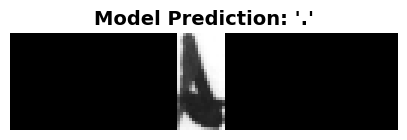

In [17]:
test_image_path = df['image_path'].iloc[0]
true_label = df['label'].iloc[0]

print(f"True Ground Label: '{true_label}'")
predicted_text = predict_and_display(test_image_path)

In [18]:


def read_my_handwriting(custom_image_path):
    print(f"Loading custom image from: {custom_image_path}")
    
    img_raw = tf.io.read_file(custom_image_path)
    
    img = tf.image.decode_image(img_raw, channels=1, expand_animations=False) 
    
   
    img = tf.cast(img, tf.float32) / 255.0
    
   
    img = tf.image.resize_with_pad(img, target_height=IMAGE_HEIGHT, target_width=IMAGE_WIDTH)
    
   
    img = tf.transpose(img, perm=[1, 0, 2])
    
   
    img_batched = tf.expand_dims(img, axis=0)
    
   
    prediction = model.predict(img_batched, verbose=0)
    
    
    extracted_text = decode_predictions(prediction)[0]
    
   
    display_img = tf.transpose(img, perm=[1, 0, 2]) 
    
    plt.figure(figsize=(6, 3))
    plt.imshow(display_img.numpy().squeeze(), cmap='gray')
    plt.title(f"Extracted Text: {extracted_text}", fontsize=16, fontweight='bold', color='darkblue')
    plt.axis('off')
    plt.show()
    
    return extracted_text



Loading custom image from: C:\Users\Ruturaj\Downloads\R.jpeg


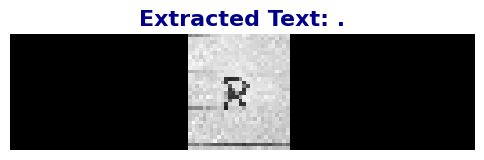

Final output string: .


In [26]:

my_image ="C:\\Users\\Ruturaj\\Downloads\\R.jpeg"
    


result = read_my_handwriting(my_image)
print("Final output string:", result)

In [33]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

def segment_sentence(image_path):
    print(f"Processing sentence from: {image_path}")
    
    
    img = cv2.imread(image_path)
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    
    
    _, thresh = cv2.threshold(gray, 0, 255, cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU)
    
    
    kernel = cv2.getStructuringElement(cv2.MORPH_RECT, (15, 3))
    dilated = cv2.dilate(thresh, kernel, iterations=1)
    
    
    contours, _ = cv2.findContours(dilated, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    
    
    bounding_boxes = [cv2.boundingRect(c) for c in contours]
    bounding_boxes = sorted(bounding_boxes, key=lambda b: b[0])
    
    word_crops = []
    
    
    for x, y, w, h in bounding_boxes:
        
        if w > 15 and h > 15: 
            
            pad = 5
            x1 = max(0, x - pad)
            y1 = max(0, y - pad)
            x2 = min(gray.shape[1], x + w + pad)
            y2 = min(gray.shape[0], y + h + pad)
            
            crop = gray[y1:y2, x1:x2]
            word_crops.append(crop)
            
    return word_crops, img

def read_sentence(image_path):
    
    word_crops, original_img = segment_sentence(image_path)
    
    full_sentence = []
    
    plt.figure(figsize=(10, 2))
    plt.imshow(cv2.cvtColor(original_img, cv2.COLOR_BGR2RGB))
    plt.title("Original Sentence Image")
    plt.axis('off')
    plt.show()
    
    print("Reading words...")
    
   
    for i, crop in enumerate(word_crops):
       
        img_tensor = tf.expand_dims(crop, axis=-1)
        
        
        img_tensor = tf.cast(img_tensor, tf.float32) / 255.0
        img_tensor = tf.image.resize_with_pad(img_tensor, target_height=IMAGE_HEIGHT, target_width=IMAGE_WIDTH)
        
       
        img_tensor = tf.transpose(img_tensor, perm=[1, 0, 2])
        img_tensor = tf.expand_dims(img_tensor, axis=0)
        
        
        prediction = model.predict(img_tensor, verbose=0)
        word_text = decode_predictions(prediction)[0]
        
        if word_text:
            full_sentence.append(word_text)
            
       
        plt.figure(figsize=(2, 1))
        plt.imshow(crop, cmap='gray')
        plt.title(word_text, fontsize=10)
        plt.axis('off')
        plt.show()
        
    final_output = " ".join(full_sentence)
    print("\n===============================")
    print(f"FINAL EXTRACTED TEXT:\n{final_output}")
    print("===============================\n")
    
    return final_output



Processing sentence from: C:\Users\Ruturaj\Downloads\Happy.jpeg


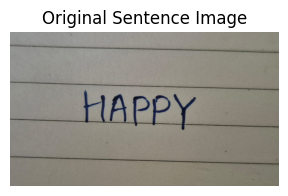

Reading words...


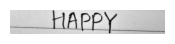


FINAL EXTRACTED TEXT:




In [34]:

test_sentence_path = "C:\\Users\\Ruturaj\\Downloads\\Happy.jpeg"
result = read_sentence(test_sentence_path)